# 03 — Multicollinearity, Multivariate Regression, PCA

Three things happen here:

1. **Diagnose multicollinearity** — factor correlation matrix + hierarchical clustering → group factors into economic buckets.
2. **Pick representatives** — one or two factors per bucket, so the multivariate model has ρ<0.8 across regressors.
3. **Multivariate regressions** — full-set vs pruned-set vs Lasso-selected, for each portfolio. Compare R², VIF, and check that the pruned set keeps most of the explanatory power.
4. **Orthogonal regression (PCA)** — as the slides recommend, validate that β estimates don't collapse when factors are made orthogonal.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns

DATA = Path('..').resolve() / 'data'
assets  = pd.read_csv(DATA / 'assets_excess.csv',  index_col=0, parse_dates=True)
factors = pd.read_csv(DATA / 'factors_excess.csv', index_col=0, parse_dates=True)
scores  = pd.read_csv(DATA / 'univariate_factor_scores.csv', index_col=0)
print('Assets :', assets.shape, '| Factors:', factors.shape)

Assets : (120, 6) | Factors: (120, 26)


## 3.1 — Factor correlation + clustering

High ρ (>0.8) pairs are the ones that will trigger VIF problems. We convert ρ to a distance (1-|ρ|), run Ward linkage, and cut at a distance of 0.2 (≈ ρ=0.8) to form buckets.

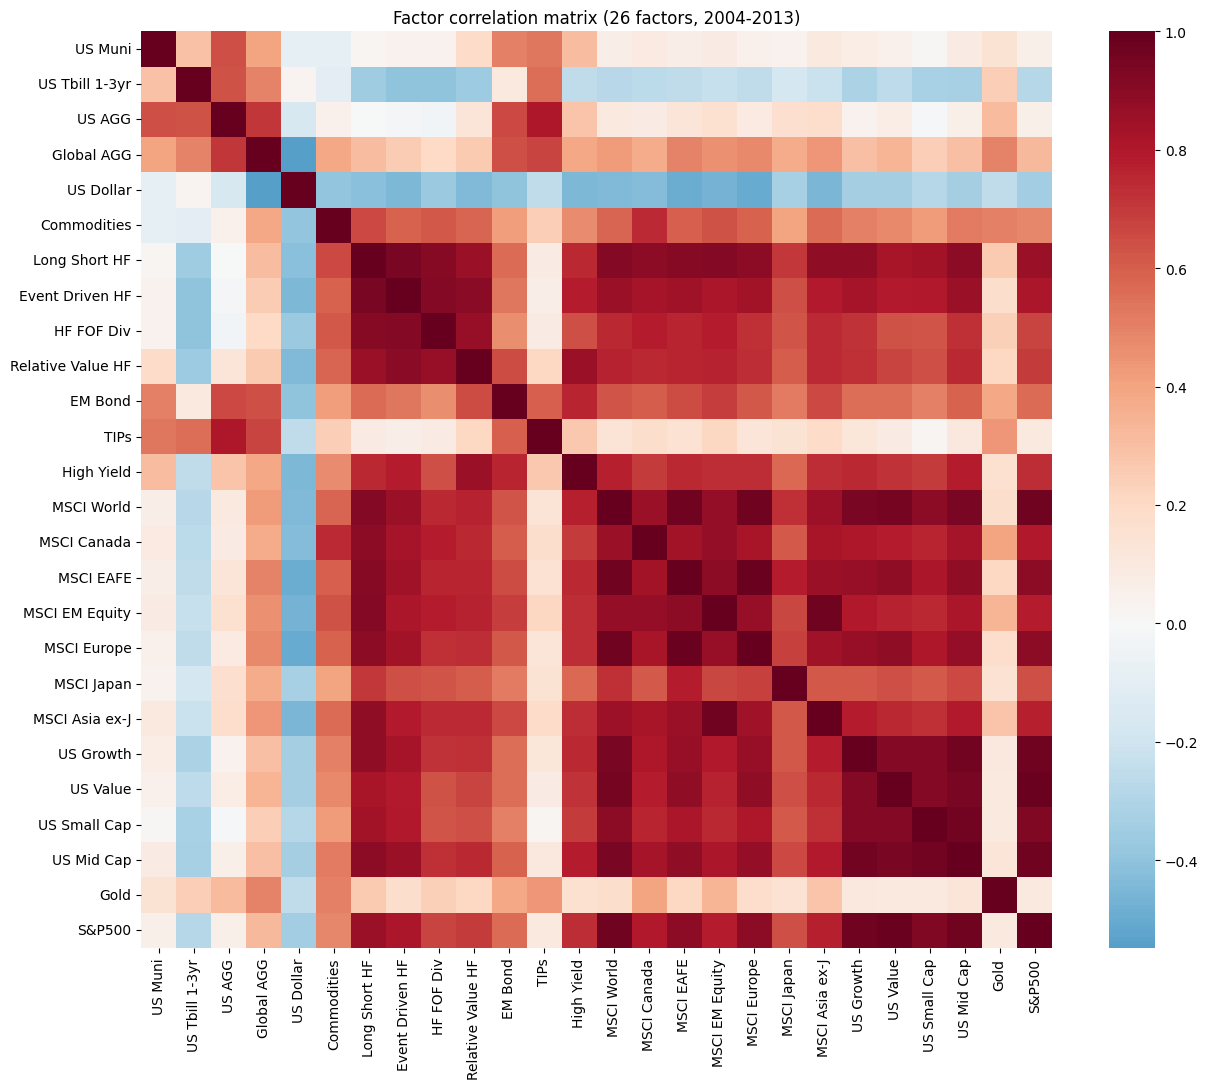

In [2]:
corr = factors.corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax)
ax.set_title('Factor correlation matrix (26 factors, 2004-2013)')
plt.tight_layout(); plt.show()

In [3]:
# Cluster on 1 - |corr|
dist = 1 - corr.abs()
np.fill_diagonal(dist.values, 0.0)
condensed = squareform(dist.values, checks=False)
Z = linkage(condensed, method='average')
clusters = fcluster(Z, t=0.2, criterion='distance')   # cut at ρ=0.8

bucket = (pd.DataFrame({'factor': corr.columns, 'cluster': clusters})
            .merge(scores[['median_rsq','hits_95','sign_consistency']], left_on='factor', right_index=True)
            .sort_values(['cluster','median_rsq'], ascending=[True, False]))
print(f'Clusters formed: {bucket["cluster"].nunique()}')
bucket

Clusters formed: 12


,factor,cluster,median_rsq,hits_95,sign_consistency
8,HF FOF Div,1,0.332304,4.0,0.666667
6,Long Short HF,1,0.330205,4.0,0.666667
7,Event Driven HF,1,0.286502,4.0,0.666667
9,Relative Value HF,1,0.208913,5.0,0.666667
14,MSCI Canada,2,0.341465,5.0,0.666667
16,MSCI EM Equity,2,0.319330,5.0,1.000000
15,MSCI EAFE,2,0.276290,5.0,0.666667
19,MSCI Asia ex-J,2,0.268560,5.0,1.000000
17,MSCI Europe,2,0.264619,5.0,0.666667
13,MSCI World,2,0.254140,5.0,0.666667


### Pick a representative per cluster

Rule: within each cluster, keep the factor with the highest `median_rsq` from the univariate screen.  (If a cluster has only one member, it's its own representative.)

In [4]:
reps = (bucket.sort_values('median_rsq', ascending=False)
              .drop_duplicates(subset=['cluster'])
              .sort_values('cluster'))
print('Representatives chosen:')
reps

Representatives chosen:


,factor,cluster,median_rsq,hits_95,sign_consistency
8,HF FOF Div,1,0.332304,4.0,0.666667
14,MSCI Canada,2,0.341465,5.0,0.666667
10,EM Bond,3,0.251302,6.0,1.000000
12,High Yield,4,0.198332,4.0,1.000000
18,MSCI Japan,5,0.151720,5.0,1.000000
5,Commodities,6,0.222474,5.0,0.666667
4,US Dollar,7,0.095636,5.0,1.000000
11,TIPs,8,0.070631,3.0,1.000000
3,Global AGG,9,0.193376,6.0,1.000000
1,US Tbill 1-3yr,10,0.076089,3.0,0.000000


In [5]:
pruned_cols = reps['factor'].tolist()
print(f'{len(pruned_cols)} pruned factors:', pruned_cols)

12 pruned factors: ['HF FOF Div', 'MSCI Canada', 'EM Bond', 'High Yield', 'MSCI Japan', 'Commodities', 'US Dollar', 'TIPs', 'Global AGG', 'US Tbill 1-3yr', 'US Muni', 'Gold']


## 3.2 — Multivariate regression: full vs pruned vs Lasso

We compare for each portfolio:
- **Full** — all 26 factors (expect high R², inflated SEs, unstable betas).
- **Pruned** — representatives from §3.1.
- **Lasso** — LassoCV on the full set (data-driven sparse model; a sanity check that our manually pruned set is not missing something obvious).

In [6]:
def ols(y, X):
    X_ = sm.add_constant(X)
    return sm.OLS(y, X_).fit()

def vif_frame(X):
    Xc = sm.add_constant(X)
    return pd.Series({col: variance_inflation_factor(Xc.values, i)
                      for i, col in enumerate(Xc.columns) if col != 'const'})

summary_rows = []
lasso_picks  = {}
for a in assets.columns:
    y = assets[a]
    full   = ols(y, factors)
    pruned = ols(y, factors[pruned_cols])
    # Lasso on standardized features
    scaler = StandardScaler().fit(factors.values)
    Xs = scaler.transform(factors.values)
    lasso = LassoCV(cv=5, max_iter=20000, random_state=0).fit(Xs, y.values)
    picked = [c for c, b in zip(factors.columns, lasso.coef_) if abs(b) > 1e-8]
    lasso_picks[a] = picked
    summary_rows.append({
        'portfolio'       : a,
        'R2_full'         : full.rsquared,
        'adjR2_full'      : full.rsquared_adj,
        'R2_pruned'       : pruned.rsquared,
        'adjR2_pruned'    : pruned.rsquared_adj,
        'n_lasso_factors' : len(picked),
        'lasso_R2'        : lasso.score(Xs, y.values),
    })
pd.DataFrame(summary_rows).set_index('portfolio')

,R2_full,adjR2_full,R2_pruned,adjR2_pruned,n_lasso_factors,lasso_R2
portfolio,,,,,,
Asset 1,0.881809,0.848766,0.782462,0.758065,5,0.831858
Asset 2,0.932341,0.913425,0.694512,0.660252,2,0.874459
Asset 3,0.647324,0.548727,0.562934,0.513918,9,0.587448
Asset 4,0.756912,0.688952,0.650142,0.610906,15,0.707455
Asset 5,0.976442,0.969856,0.970849,0.967580,8,0.969481
EWP,0.847249,0.804545,0.769740,0.743916,9,0.824878


In [7]:
# Which factors did Lasso pick for multiple portfolios?
lasso_hits = pd.Series([f for lst in lasso_picks.values() for f in lst]).value_counts()
lasso_hits.name = 'n_portfolios_picked_by_lasso'
lasso_hits

Gold                 5
US Dollar            4
US Tbill 1-3yr       3
TIPs                 3
HF FOF Div           3
US Growth            3
Commodities          3
Event Driven HF      3
MSCI EM Equity       3
High Yield           2
US AGG               2
US Small Cap         2
US Muni              2
Global AGG           2
MSCI Canada          2
MSCI Japan           1
MSCI Europe          1
EM Bond              1
Relative Value HF    1
US Value             1
US Mid Cap           1
Name: n_portfolios_picked_by_lasso, dtype: int64

## 3.3 — VIF on the pruned set (should be < 5 target)

In [8]:
vifs = vif_frame(factors[pruned_cols]).sort_values(ascending=False)
print('VIF on pruned factors (target < 5):')
vifs

VIF on pruned factors (target < 5):


EM Bond           5.074889
MSCI Canada       4.956868
Global AGG        4.325367
High Yield        4.175875
HF FOF Div        3.494123
Commodities       3.206468
TIPs              3.070022
US Tbill 1-3yr    2.835767
MSCI Japan        2.198782
US Muni           1.967815
US Dollar         1.882688
Gold              1.816793
dtype: float64

## 3.4 — Multivariate β table across portfolios

The real test for **cross-portfolio** stability: do the β signs and rough magnitudes line up across all six portfolios when we run the pruned multivariate?

In [9]:
beta_tbl = pd.DataFrame(index=pruned_cols, columns=assets.columns, dtype=float)
tstat_tbl = beta_tbl.copy()
for a in assets.columns:
    m = ols(assets[a], factors[pruned_cols])
    for f in pruned_cols:
        beta_tbl.loc[f, a]  = m.params[f]
        tstat_tbl.loc[f, a] = m.tvalues[f]
beta_tbl

,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,EWP
HF FOF Div,-0.033828,0.590843,0.391778,0.671167,-0.074528,0.309086
MSCI Canada,0.001521,0.620145,0.222136,0.008322,-0.013568,0.167711
EM Bond,0.151657,-0.194962,0.002824,-0.163739,-0.013835,-0.043611
High Yield,-0.049836,0.569608,0.198360,-0.129047,0.140272,0.145871
MSCI Japan,-0.000622,-0.066371,-0.041014,0.019137,0.006718,-0.016430
Commodities,-0.025346,-0.310879,0.585365,0.028496,0.001163,0.055760
US Dollar,0.017147,0.396093,-0.318139,0.064150,-0.034450,0.024960
TIPs,0.083066,0.185243,-0.205149,-0.115090,0.932841,0.176182
Global AGG,0.019041,0.721541,0.347037,0.302853,-0.003821,0.277330
US Tbill 1-3yr,0.725036,-1.687814,0.086484,0.632393,-0.037602,-0.056301


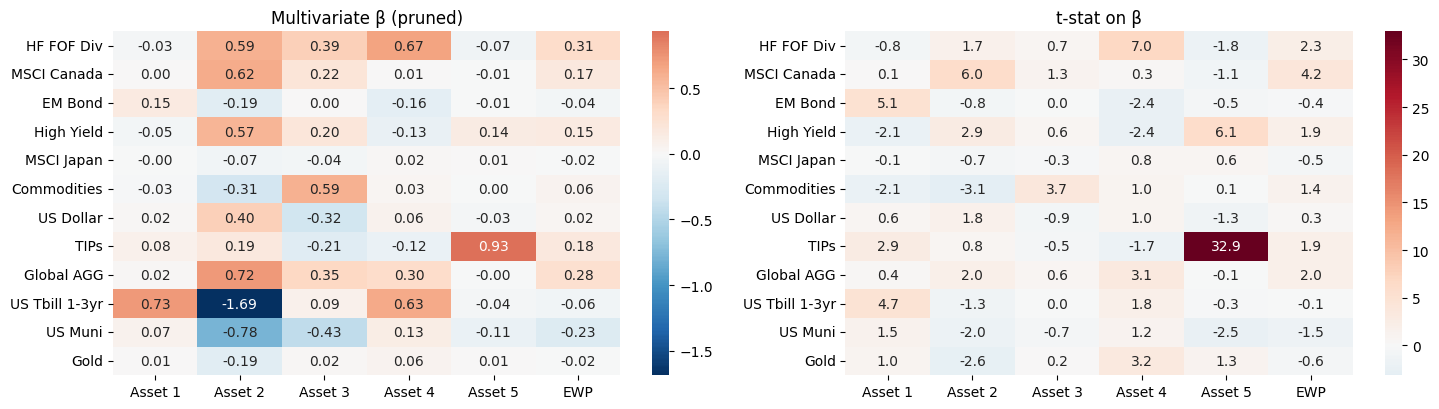

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(4, 0.35*len(pruned_cols))))
sns.heatmap(beta_tbl.astype(float),  annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Multivariate β (pruned)')
sns.heatmap(tstat_tbl.astype(float), annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('t-stat on β')
plt.tight_layout(); plt.show()

### Cross-portfolio stability on the pruned multivariate

In [11]:
mv_scores = pd.DataFrame({
    'mv_hits_95'         : (tstat_tbl.abs() > 1.96).sum(axis=1),
    'mv_hits_90'         : (tstat_tbl.abs() > 1.65).sum(axis=1),
    'mv_sign_consistency': np.abs(np.sign(beta_tbl.astype(float)).mean(axis=1)),
    'mv_beta_mean'       : beta_tbl.astype(float).mean(axis=1),
    'mv_beta_std'        : beta_tbl.astype(float).std(axis=1, ddof=1),
})
mv_scores.sort_values(['mv_hits_95','mv_sign_consistency'], ascending=False)

,mv_hits_95,mv_hits_90,mv_sign_consistency,mv_beta_mean,mv_beta_std
High Yield,4,5,0.333333,0.145871,0.243401
Global AGG,3,3,0.666667,0.277330,0.264043
Commodities,3,3,0.333333,0.055760,0.291619
MSCI Canada,2,2,0.666667,0.167711,0.242299
HF FOF Div,2,4,0.333333,0.309086,0.310508
EM Bond,2,2,0.333333,-0.043611,0.125308
TIPs,2,4,0.333333,0.176182,0.402874
US Muni,2,2,0.333333,-0.226376,0.339624
Gold,2,2,0.333333,-0.017375,0.086050
US Tbill 1-3yr,1,2,0.000000,-0.056301,0.868027


## 3.5 — Orthogonal regression (PCA)

Sanity check recommended in the slides: replace the factor block with its principal components, regress, and map back to original-factor betas. Unstable loadings in the raw multivariate usually become stable when you project through the top PCs.

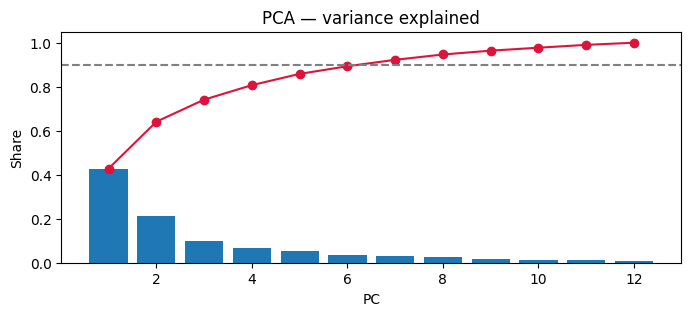

In [12]:
X = factors[pruned_cols].values
Xmu, Xsd = X.mean(axis=0), X.std(axis=0, ddof=1)
Xs = (X - Xmu) / Xsd
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
plt.figure(figsize=(8,3))
plt.bar(range(1, len(evr)+1), evr)
plt.plot(range(1, len(evr)+1), np.cumsum(evr), 'o-', color='crimson')
plt.axhline(0.9, ls='--', color='grey')
plt.title('PCA — variance explained'); plt.xlabel('PC'); plt.ylabel('Share')
plt.show()

In [13]:
K = int(np.argmax(np.cumsum(evr) >= 0.9) + 1)  # PCs needed for 90% variance
print(f'Use K={K} PCs to capture 90% of factor-set variance.')
P = pca.transform(Xs)[:, :K]
W = pca.components_[:K]             # K x p

# For each asset, run OLS on PCs then map back: β_factor = W.T @ β_pc (on standardized X)
pc_beta_tbl = pd.DataFrame(index=pruned_cols, columns=assets.columns, dtype=float)
for a in assets.columns:
    m = sm.OLS(assets[a].values, sm.add_constant(P)).fit()
    b_pc = m.params[1:]
    b_std = W.T @ b_pc              # betas on standardized factors
    b_raw = b_std / Xsd             # un-standardize
    pc_beta_tbl[a] = b_raw
print('Orthogonal-regression (PCA) β back-mapped to factors:')
pc_beta_tbl

Use K=7 PCs to capture 90% of factor-set variance.
Orthogonal-regression (PCA) β back-mapped to factors:


,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,EWP
HF FOF Div,-0.080639,0.576766,0.805175,0.391963,-0.129515,0.312750
MSCI Canada,-0.009654,0.133993,0.216424,0.043955,0.007163,0.078376
EM Bond,0.062534,0.295659,0.002118,-0.178499,0.197703,0.075903
High Yield,0.011461,0.415562,0.161773,-0.168945,0.118248,0.107620
MSCI Japan,0.008655,0.156788,-0.067214,0.073480,-0.048876,0.024567
Commodities,-0.013864,0.112333,0.460650,0.060593,0.057687,0.135480
US Dollar,0.052677,0.030511,-0.407545,-0.033532,0.050205,-0.061537
TIPs,0.095547,0.001266,0.196438,-0.024796,0.331119,0.119915
Global AGG,0.086393,-0.102639,0.142337,0.066654,0.214331,0.081415
US Tbill 1-3yr,0.549748,-1.856546,-0.175719,0.546231,1.339024,0.080548


In [14]:
# Compare OLS β to PCA-back-mapped β
diff = (pc_beta_tbl.astype(float) - beta_tbl.astype(float))
print('|Δβ| per factor (max across portfolios):')
diff.abs().max(axis=1).sort_values(ascending=False)

|Δβ| per factor (max across portfolios):


US Tbill 1-3yr    1.376626
Global AGG        0.824180
US Muni           0.700464
TIPs              0.601722
EM Bond           0.490621
MSCI Canada       0.486152
Commodities       0.423212
HF FOF Div        0.413397
US Dollar         0.365582
MSCI Japan        0.223159
High Yield        0.154045
Gold              0.027826
dtype: float64

## 3.6 — Persist outputs for the stability notebook

In [15]:
bucket.to_csv(DATA / 'factor_clusters.csv', index=False)
reps.to_csv(DATA / 'factor_cluster_reps.csv', index=False)
beta_tbl.to_csv(DATA / 'mv_beta_pruned.csv')
tstat_tbl.to_csv(DATA / 'mv_tstat_pruned.csv')
mv_scores.to_csv(DATA / 'mv_factor_scores.csv')
pd.Series(lasso_picks).to_json(DATA / 'lasso_picks.json')
print('saved.')

saved.
